Copyright 2026 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

     https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

# 🚀 Columnar Engine Accelerated Hnsw Vector Search Benchmark

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GoogleCloudPlatform/python-docs-samples/blob/main/alloydb/notebooks/columnar_engine_accelerated_hnsw_vector_search_benchmark.ipynb)

---
This interactive notebook measures the performance impact of **AlloyDB's Columnar Engine** on **pgvector HNSW** indexes. Visit [Get Started with AlloyDB](https://cloud.google.com/alloydb/docs/quickstart).

*(Note: The performance metrics demonstrated in this notebook were captured using an **AlloyDB C4A 16-vCPU** instance. Your results may vary based on machine type & size).*

🚨 **IMPORTANT PREREQUISITES:**

Before running this notebook, verify the following requirements:
1. **PostgreSQL 17+**: Ensure you have an **AlloyDB for PostgreSQL 17 (or greater)** cluster created. (HNSW Columnar Engine caching is not supported on PG14/PG15/PG16).
2. **Public IP** is enabled on the instance (Note: there is no need to authorize any networks!).
3. The following **Database Flags** are configured on your AlloyDB primary instance:
   * `google_columnar_engine.enabled` = `on`
   * `google_columnar_engine.enable_index_caching` = `on`
   * `google_columnar_engine.memory_size_in_mb` = `1024` (or larger)

📚 **Helpful Resources:**

* [Get Started with AlloyDB](https://cloud.google.com/alloydb/docs/quickstart)
* [Accelerate vector search with the columnar engine](https://docs.cloud.google.com/alloydb/docs/ai/accelerate-with-ce)
* [pgvector](https://github.com/pgvector/pgvector)
---

✅ Output cleared. Colab Setup successful!


Downloading dataset (1.2GB) from ann-benchmarks.com...

COPY Training Data:   0%|          | 0/119 [00:00<?, ?it/s]

COPY Test Queries & Ground Truth:   0%|          | 0/1 [00:00<?, ?it/s]

Building HNSW Index:   0%|          | 0/100 [00:00<?, ?it/s]

...

[16:00:37] ef: 40 | qps: 6914 | recall: 0.794                                                      ]8;id=885005;file:///tmp/ipykernel_618/300156691.py\300156691.py]8;;\:]8;id=750935;file:///tmp/ipykernel_618/300156691.py#274\274]8;;\

           ef: 100 | qps: 3427 | recall: 0.879                                                     ]8;id=138631;file:///tmp/ipykernel_618/300156691.py\300156691.py]8;;\:]8;id=994064;file:///tmp/ipykernel_618/300156691.py#274\274]8;;\

[16:00:39] ef: 200 | qps: 1891 | recall: 0.923                                                     ]8;id=1464;file:///tmp/ipykernel_618/300156691.py\300156691.py]8;;\:]8;id=53611;file:///tmp/ipykernel_618/300156691.py#274\274]8;;\

[16:00:41] ef: 400 | qps: 1015 | recall: 0.957                                                     ]8;id=90936;file:///tmp/ipykernel_618/300156691.py\300156691.py]8;;\:]8;id=124803;file:///tmp/ipykernel_618/300156691.py#274\274]8;;\

[16:00:45] ef: 800 | qps: 520 | recall: 0.979                                                      ]8;id=350436;file:///tmp/ipykernel_618/300156691.py\300156691.py]8;;\:]8;id=417242;file:///tmp/ipykernel_618/300156691.py#274\274]8;;\

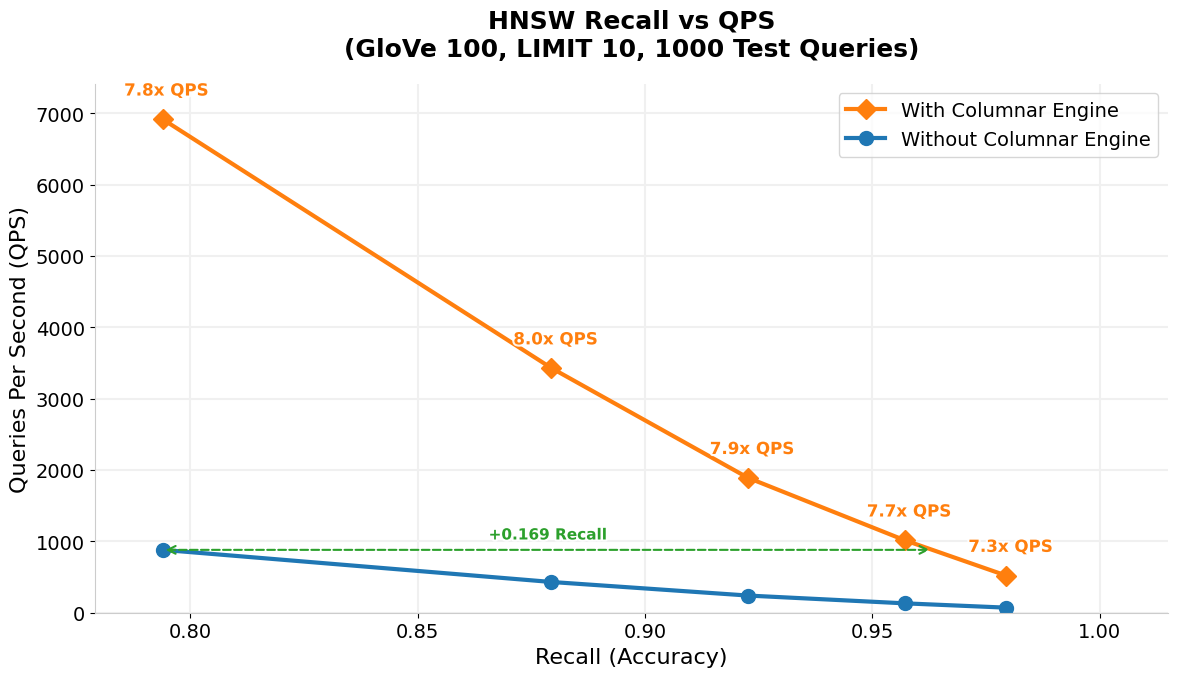

In [1]:
# @title ⚙️ Benchmark Execution
# ==========================================
# 1. CONFIGURATION
# ==========================================
# @markdown ### **⚙️ 1. Cluster Configuration**
project_id = "" # @param {type:"string", placeholder:"Project ID"}
region = "" # @param {type:"string", placeholder: "Region (e.g. us-central1)"}
cluster_name = "" # @param {type:"string", placeholder: "Cluster name"}
instance_name = "" # @param {type:"string", placeholder: "Instance Name"}

# @markdown ### **🔐 2. Database Credentials**
# @markdown *Note: Password will be requested securely when the benchmark is executed.*
db_user = "" # @param {type:"string", placeholder: "DB User"}
db_name = "" # @param {type:"string", placeholder: "DB Name"}

# @markdown ### **⚙️ 3. Benchmark Settings**
# @markdown *Note: Increasing these values will provide more intensive testing, but will slow down the benchmark runtime.*
# @markdown * `test_queries`: The total number of test queries to run during the benchmark. Increasing this value provides a more stable average but slows down the overall runtime.
# @markdown * `search_limit`: The number of nearest neighbors to retrieve per query (i.e., the `LIMIT` on the vector similarity search, equivalent to top-k).

test_queries = 1000 # @param [100, 1000, 10000] {type:"raw"}
search_limit = 10 # @param [10, 100] {type:"raw"}
vector_dim = 100 # Fixed for GloVe-100 dataset

import getpass
# Prompt for password upfront so user doesn't wait for the pip installation
db_pass = getpass.getpass("🔑 Enter Database Password for AlloyDB: ")

# ==========================================
# 2. SETUP & AUTHENTICATION
# ==========================================
import os
print("📦 Installing dependencies silently... (This takes ~15 seconds)")
%pip install -q h5py matplotlib asyncpg google-cloud-alloydb-connector[asyncpg] tqdm rich pgvector

print("🔐 Authenticating with Google Cloud...")
from google.colab import auth
auth.authenticate_user()

from IPython.display import clear_output
clear_output()
print("✅ Output cleared. Colab Setup successful!")

# ==========================================
# 3. LATE IMPORTS (Post-Installation)
# ==========================================
import asyncio
import urllib.request
import shutil
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.notebook import tqdm
from rich.console import Console
from rich.panel import Panel
from rich.markdown import Markdown
from google.cloud.alloydb.connector import AsyncConnector
import pgvector.asyncpg
from pgvector.asyncpg import register_vector
from IPython.display import display, HTML

console = Console()

def print_step(step_label, text="", is_success=False, is_error=False):
    # Base styling (font size and spacing)
    base_style = "font-size: 17px; margin-top: 10px; margin-bottom: 4px;"

    if is_success:
        # Success: Fully bold, Universal Material Green
        display(HTML(f'''
        <div style="{base_style} font-weight: bold; color: #34A853;">
            {step_label} {text}
        </div>
        '''))
    elif is_error:
        # Error: Fully bold, Universal Material Red
        display(HTML(f'''
        <div style="{base_style} font-weight: bold; color: #EA4335;">
            {step_label} {text}
        </div>
        '''))
    else:
        # Steps: Label is bold and colored; Text is normal weight and theme-adaptive
        display(HTML(f'''
        <div style="{base_style}">
            <span style="color: var(--colab-anchor-color); font-weight: bold;">{step_label}</span>
            <span style="color: var(--colab-primary-text-color);">{text}</span>
        </div>
        '''))

# ==========================================
# 4. SQL DEFINITIONS (Optimized with Array Intersection)
# ==========================================
SQL_MEASURE_RECALL = """
CREATE OR REPLACE FUNCTION measure_recall(ef INT, num_q INT) RETURNS FLOAT AS $func$
DECLARE
    q_rec record; total_recall FLOAT := 0; retrieved_ids INT[]; intersect_count INT;
BEGIN
    PERFORM set_config('hnsw.ef_search', ef::text, false);

    FOR q_rec IN SELECT embedding, ground_truth FROM glove_test LIMIT num_q LOOP
        SELECT array_agg(sub.id) INTO retrieved_ids FROM (
            SELECT id FROM glove ORDER BY embedding <=> q_rec.embedding LIMIT __SEARCH_LIMIT__
        ) sub;

        -- Instant Intersection of retrieved array and ground_truth[1:search_limit]
        SELECT count(*) INTO intersect_count
        FROM unnest(retrieved_ids) as r
        JOIN unnest(q_rec.ground_truth[1:__SEARCH_LIMIT__]) as g ON r = g;

        total_recall := total_recall + (intersect_count::FLOAT / __SEARCH_LIMIT__);
    END LOOP;

    RETURN total_recall / num_q;
END;
$func$ LANGUAGE plpgsql;
""".replace("__SEARCH_LIMIT__", str(search_limit))

SQL_MEASURE_QPS = """
CREATE OR REPLACE FUNCTION measure_qps(ef INT, num_q INT) RETURNS FLOAT AS $func$
DECLARE
    start_time timestamp; end_time timestamp; q_vec halfvec;
BEGIN
    PERFORM set_config('hnsw.ef_search', ef::text, false);

    start_time := clock_timestamp();
    FOR q_vec IN SELECT embedding FROM glove_test LIMIT num_q LOOP
        PERFORM id FROM glove ORDER BY embedding <=> q_vec LIMIT __SEARCH_LIMIT__;
    END LOOP;
    end_time := clock_timestamp();

    RETURN num_q / (extract(epoch from end_time) - extract(epoch from start_time));
END;
$func$ LANGUAGE plpgsql;
""".replace("__SEARCH_LIMIT__", str(search_limit))

# ==========================================
# 5. CORE FUNCTIONS
# ==========================================
async def verify_columnar_flags(conn):
    print_step("Step 2/9:", "🔍 Verifying PostgreSQL Version & Columnar Engine Flags...")

    # 1. Verify PostgreSQL Version (Requires PG17+)
    pg_version = await conn.fetchval("SHOW server_version_num;")
    if not pg_version or int(pg_version) < 170000:
        actual_ver = await conn.fetchval("SHOW server_version;")
        print_step("❌", f"PostgreSQL version is {actual_ver}. HNSW Columnar Engine caching is only supported on PostgreSQL 17 or higher.", is_error=True)
        raise RuntimeError("Unsupported PostgreSQL Version.")

    # 2. Fetch Columnar Engine GUC Settings
    enabled = await conn.fetchval("SELECT current_setting('google_columnar_engine.enabled', true);")
    caching = await conn.fetchval("SELECT current_setting('google_columnar_engine.enable_index_caching', true);")
    mem_size = await conn.fetchval("SELECT current_setting('google_columnar_engine.memory_size_in_mb', true);")

    warnings = []
    if enabled != 'on':
        warnings.append("google_columnar_engine.enabled is NOT 'on'")
    if caching != 'on':
        warnings.append("google_columnar_engine.enable_index_caching is NOT 'on'")
    if not mem_size or int(mem_size) < 1024:
        warnings.append(f"memory_size_in_mb is '{mem_size}' (Must be at least 1024)")

    if warnings:
        for w in warnings:
            print_step("❌", w, is_error=True)
        raise RuntimeError("Missing required Database Flags. Please update your cluster settings and restart.")
    else:
        print_step("✅", "PostgreSQL version and Columnar Engine flags are properly configured!", is_success=True)

async def fast_bulk_insert_train(conn, data_array, batch_size=10000, desc=""):
    for i in tqdm(range(0, len(data_array), batch_size), desc=desc, leave=True, colour='#1f77b4'):
        batch = data_array[i:i + batch_size]
        records = [(i + j + 1, emb.tolist()) for j, emb in enumerate(batch)]
        await conn.copy_records_to_table("glove", columns=["id", "embedding"], records=records)

async def fast_bulk_insert_test(conn, data_array, neighbors_array, batch_size=10000, desc=""):
    for i in tqdm(range(0, len(data_array), batch_size), desc=desc, leave=True, colour='#1f77b4'):
        batch_d = data_array[i:i + batch_size]
        batch_n = neighbors_array[i:i + batch_size]
        records = [(i + j + 1, emb.tolist(), [int(x+1) for x in nbr]) for j, (emb, nbr) in enumerate(zip(batch_d, batch_n))]
        await conn.copy_records_to_table("glove_test", columns=["id", "embedding", "ground_truth"], records=records)

async def prepare_dataset(conn):
    print_step("Step 4/9:", "📥 Preparing GloVe Dataset...")
    if not os.path.exists("glove-100-angular.hdf5"):
        console.print("         [dim]Downloading dataset (1.2GB) from ann-benchmarks.com...[/dim]")
        url = "http://ann-benchmarks.com/glove-100-angular.hdf5"
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open("glove-100-angular.hdf5", "wb") as out_file:
            shutil.copyfileobj(response, out_file)

    print_step("Step 5/9:", "📂 Loading dataset and inserting via COPY...")
    with h5py.File("glove-100-angular.hdf5", "r") as f:
        train_data = f['train'][:]
        test_data = f['test'][:]
        neighbors_data = f['neighbors'][:]

    await fast_bulk_insert_train(conn, train_data, desc="COPY Training Data")
    await fast_bulk_insert_test(conn, test_data, neighbors_data, desc="COPY Test Queries & Ground Truth")

async def monitor_index_progress(connector):
    try:
        poll_conn = await connector.connect(
            f"projects/{project_id}/locations/{region}/clusters/{cluster_name}/instances/{instance_name}",
            "asyncpg", user=db_user, password=db_pass, db=db_name, ip_type="PUBLIC"
        )
    except Exception:
        return

    try:
        with tqdm(total=100, desc="Building HNSW Index", colour='#00ff00') as pbar:
            while True:
                try:
                    progress = await poll_conn.fetchrow("""
                        SELECT blocks_done, blocks_total, phase
                        FROM pg_stat_progress_create_index
                        WHERE relid = 'glove'::regclass
                    """)
                    if progress and progress['blocks_total'] > 0:
                        percent = (progress['blocks_done'] / progress['blocks_total']) * 100
                        pbar.n = round(percent, 1)
                        pbar.set_postfix_str(f"Phase: {progress['phase']}")
                        pbar.refresh()
                except Exception:
                    pass
                await asyncio.sleep(1)
    except asyncio.CancelledError:
        pass
    finally:
        try:
            await poll_conn.close()
        except Exception:
            pass

async def build_index(conn, connector):
    print_step("Step 6/9:", "🧹 Updating database planner statistics...")
    await conn.execute("VACUUM (DISABLE_PAGE_SKIPPING, ANALYZE) glove;")
    await conn.execute("VACUUM (DISABLE_PAGE_SKIPPING, ANALYZE) glove_test;")

    print_step("Step 7/9:", "🏗️ Building HNSW Index...")
    await conn.execute("DROP INDEX IF EXISTS my_hnsw_idx;")
    await conn.execute("SET max_parallel_maintenance_workers = 16;")
    await conn.execute("SET maintenance_work_mem = '3GB';")

    monitor_task = asyncio.create_task(monitor_index_progress(connector))
    try:
        await conn.execute("CREATE INDEX my_hnsw_idx ON glove USING hnsw (embedding halfvec_cosine_ops) WITH (m = 24, ef_construction = 256);")
    finally:
        monitor_task.cancel()

async def run_evaluations(conn, ef_values, test_queries):
    print_step("Step 8/9:", "⚙️ Deploying Benchmark PL/pgSQL Functions...")
    await conn.execute(SQL_MEASURE_RECALL)
    await conn.execute(SQL_MEASURE_QPS)

    print_step("Step 9/9:", "⏱️ Running Benchmarks...")
    results_without_ce = []
    results_with_ce = []

    # Run WITHOUT Columnar Engine
    await conn.execute("SELECT google_columnar_engine_drop_index('my_hnsw_idx');")
    for ef in tqdm(ef_values, desc="Without Columnar Engine", leave=True, colour='#1f77b4'):
        recall = await conn.fetchval(f"SELECT measure_recall({ef}, {test_queries});")
        qps = await conn.fetchval(f"SELECT measure_qps({ef}, {test_queries});")
        console.log("ef: %d | qps: %d | recall: %.3f" % (ef, qps, recall))
        results_without_ce.append((ef, recall, qps))

    # Run WITH Columnar Engine
    await conn.execute("SELECT google_columnar_engine_add_index('my_hnsw_idx');")
    for ef in tqdm(ef_values, desc="WITH Columnar Engine", leave=True, colour='#ff7f0e'):
        recall = await conn.fetchval(f"SELECT measure_recall({ef}, {test_queries});")
        qps = await conn.fetchval(f"SELECT measure_qps({ef}, {test_queries});")
        console.log("ef: %d | qps: %d | recall: %.3f" % (ef, qps, recall))
        results_with_ce.append((ef, recall, qps))

    return results_without_ce, results_with_ce

def plot_results(results_without_ce, results_with_ce):
    """Renders the final performance plot outside the async block."""
    print_step("📊", "Generating Final Plot & Summary...", is_success=True)
    import numpy as np
    import matplotlib.patheffects as patheffects

    ef_wo = [p[0] for p in results_without_ce]
    recalls_wo = [p[1] for p in results_without_ce]
    qps_wo = [p[2] for p in results_without_ce]

    ef_wi = [p[0] for p in results_with_ce]
    recalls_wi = [p[1] for p in results_with_ce]
    qps_wi = [p[2] for p in results_with_ce]

    plt.rc('font', size=14)
    plt.rc('axes', titlesize=18)
    plt.rc('axes', labelsize=16)
    plt.rc('xtick', labelsize=14)
    plt.rc('ytick', labelsize=14)
    plt.rc('legend', fontsize=14)
    plt.figure(figsize=(12, 7))

    # Google brand colors
    color_wi = '#ff7f0e' # Orange
    color_wo = '#1f77b4' # Blue
    color_ar = '#2ca02c' # Green

    plt.plot(recalls_wi, qps_wi, marker='D', linewidth=3, markersize=10,
             color=color_wi, label='With Columnar Engine')
    plt.plot(recalls_wo, qps_wo, marker='o', linewidth=3, markersize=10,
             color=color_wo, label='Without Columnar Engine')

    plt.xlabel('Recall (Accuracy)')
    plt.ylabel('Queries Per Second (QPS)')
    plt.title(f'HNSW Recall vs QPS\n(GloVe 100, LIMIT {search_limit}, {test_queries} Test Queries)', pad=20, fontweight='bold')

    max_qps = max(max(qps_wi, default=0), max(qps_wo, default=0))
    min_recall = min(min(recalls_wi, default=1), min(recalls_wo, default=1))

    plt.ylim(0, max_qps + 500)
    plt.xlim(min_recall - 0.015, 1.015)

    plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(1000))
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.05))

    # Clean up spines (borders)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_color('#cccccc')
    plt.gca().spines['bottom'].set_color('#cccccc')

    pe = [patheffects.withStroke(linewidth=3, foreground='white', alpha=0.9)]

    # --- 1. Annotate QPS improvement at the same Recall (Vertical Gap) ---
    for r_wi, q_wi, q_wo in zip(recalls_wi, qps_wi, qps_wo):
        multiplier = q_wi / q_wo if q_wo > 0 else 0
        if multiplier > 0:
            plt.text(r_wi * 1.001, q_wi + (max_qps * 0.04), f'{multiplier:.1f}x QPS', color=color_wi,
                     fontsize=12, fontweight='bold', ha='center', va='bottom', path_effects=pe)

    # --- 2. Annotate Recall improvement at the same QPS (Horizontal Gap) ---
    if len(qps_wo) > 0 and len(qps_wi) > 0:
        idx_min_recall_wo = np.argmin(recalls_wo)
        r_wo_min = recalls_wo[idx_min_recall_wo]
        q_target = qps_wo[idx_min_recall_wo]

        # Check if q_target is within the range of orange line's QPS
        if min(qps_wi) <= q_target <= max(qps_wi):
            wi_sort = np.argsort(qps_wi)
            r_wi_interp = np.interp(q_target, np.array(qps_wi)[wi_sort], np.array(recalls_wi)[wi_sort])

            if (r_wi_interp - r_wo_min) > 0.005:
                plt.annotate('', xy=(r_wi_interp, q_target), xytext=(r_wo_min, q_target),
                             arrowprops=dict(arrowstyle="<->", color=color_ar, lw=1.5, linestyle='--'))
                plt.text((r_wo_min + r_wi_interp) / 2, q_target + (max_qps * 0.015), f'+{r_wi_interp - r_wo_min:.3f} Recall',
                         color=color_ar, fontsize=11, fontweight='bold', ha='center', va='bottom', path_effects=pe)

    plt.legend(loc='upper right', frameon=True, edgecolor='#cccccc')
    plt.grid(True, which='both', color='#f0f0f0', linestyle='-', linewidth=1.5)
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. MAIN EXECUTION PIPELINE
# ==========================================
async def run_benchmark():
    connector = None
    conn = None
    try:
        print_step("✅", "GCP Authentication Successful!", is_success=True)
        print_step("🚀", "Starting AlloyDB Benchmark Pipeline...")

        print_step("Step 1/9:", "🔌 Initializing AlloyDB AsyncConnector...")
        connector = AsyncConnector()
        conn = await connector.connect(
            f"projects/{project_id}/locations/{region}/clusters/{cluster_name}/instances/{instance_name}",
            "asyncpg", user=db_user, password=db_pass, db=db_name, ip_type="PUBLIC"
        )

        await verify_columnar_flags(conn)

        print_step("Step 3/9:", "🛠️ Setting up extensions & tables...")
        await conn.execute("CREATE EXTENSION IF NOT EXISTS vector;")
        await conn.execute("CREATE EXTENSION IF NOT EXISTS google_columnar_engine;")
        await conn.execute("DROP TABLE IF EXISTS glove CASCADE;")
        await conn.execute("DROP TABLE IF EXISTS glove_test CASCADE;")
        await conn.execute(f"CREATE TABLE glove (id BIGINT PRIMARY KEY, embedding halfvec({vector_dim}));")
        await conn.execute(f"CREATE TABLE glove_test (id BIGINT PRIMARY KEY, embedding halfvec({vector_dim}), ground_truth INT[]);")

        await register_vector(conn)

        await prepare_dataset(conn)
        await build_index(conn, connector)

        ef_values = [40, 100, 200, 400, 800]
        # Return results to pass into synchronous plotter
        return await run_evaluations(conn, ef_values, test_queries)

    except Exception as e:
        print_step("❌", f"ERROR: {str(e)}", is_error=True)
        return None, None
    finally:
        if conn: await conn.close()
        if connector: await connector.close()

# Evaluate the benchmark (Async Loop)
results_wo, results_wi = await run_benchmark()

# Guarantee Plot renders perfectly (Sync Thread)
if results_wo and results_wi:
    plot_results(results_wo, results_wi)
